In [2]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))
from shared.collect_data import DataCollector
from shared.clean_data import DataCleaning
import ta
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
data_collector = DataCollector(
    symbol = "BTC/USDT", 
    timeframe = "15m", 
    days = 3,
    limit = 1000
)
df = data_collector.collect_data()

In [4]:
df.tail()

,timestamp,open,high,low,close,volume
283,2025-10-14 22:45:00,112943.79,113240.00,112822.16,113211.87,133.96048
284,2025-10-14 23:00:00,113211.87,113499.99,113133.04,113445.13,145.57828
285,2025-10-14 23:15:00,113445.12,113520.00,113347.92,113426.01,91.51705
286,2025-10-14 23:30:00,113426.01,113479.13,113266.48,113266.49,134.10114
287,2025-10-14 23:45:00,113266.48,113300.00,113022.96,113032.95,124.85049


In [5]:
df = df.iloc[:-1]

In [6]:
df.tail()

,timestamp,open,high,low,close,volume
282,2025-10-14 22:30:00,113184.63,113195.05,112916.67,112943.79,100.62952
283,2025-10-14 22:45:00,112943.79,113240.00,112822.16,113211.87,133.96048
284,2025-10-14 23:00:00,113211.87,113499.99,113133.04,113445.13,145.57828
285,2025-10-14 23:15:00,113445.12,113520.00,113347.92,113426.01,91.51705
286,2025-10-14 23:30:00,113426.01,113479.13,113266.48,113266.49,134.10114


In [7]:
##Awesome Oscillator (AO)
df["AO"] = ta.momentum.AwesomeOscillatorIndicator(
    high=df["high"],
    low=df["low"],
    window1=5,
    window2=34
).awesome_oscillator()

##KAMA
df["KAMA"] = ta.momentum.KAMAIndicator(close=df['close']).kama()

## PPO
ppo = ta.momentum.PercentagePriceOscillator(
    close=df['close'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PPO"] = ppo.ppo()

df["PPO_HIST"] = ppo.ppo_hist()

df["PPO_SIGNAL"] = ppo.ppo_signal()

## PVO
pvo = ta.momentum.PercentageVolumeOscillator(
    volume =df['volume'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PVO"] = pvo.pvo()

df["PVO_HIST"] = pvo.pvo_hist()

df["PVO_SIGNAL"] = pvo.pvo_signal()

## ROC
df["ROC"] = ta.momentum.ROCIndicator(
    close=df['close'],
    window=12
).roc()

## RSI
df["RSI"] = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()

## STOCHASTIC RSI
df["STOCH_RSI"] = ta.momentum.StochRSIIndicator(
    close=df['close'],
    window=14,
    smooth1=3,
    smooth2=3
).stochrsi()

## STOCHASTIC OSCILLATOR
stoch = ta.momentum.StochasticOscillator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    window=14,
    smooth_window=3
)

df["STOCH_OSC"] = stoch.stoch()

df["STOCH_OSC_SIGNAL"] = stoch.stoch_signal()

## TSI
df["TSI"] = ta.momentum.TSIIndicator(
    close=df['close'],
    window_slow=25,
    window_fast=13
).tsi()

In [8]:
## ADI
adi = ta.volume.AccDistIndexIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume']
)

df["ADI"] = adi.acc_dist_index()

## CMF
cmf = ta.volume.ChaikinMoneyFlowIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume'],
    window=20
)

df["CMF"] = cmf.chaikin_money_flow()

##EoM EMV
emi = ta.volume.EaseOfMovementIndicator(
    high=df["high"], low=df["low"], volume=df["volume"], window=14
)

df["EoM"] = emi.ease_of_movement()
df["EMV"] = emi.sma_ease_of_movement()

##FI
fi = ta.volume.ForceIndexIndicator(
    close=df["close"], volume=df["volume"], window=13
)

df["FI"] = fi.force_index()

##MFI
mfi = ta.volume.MFIIndicator(
    high=df["high"], low=df["low"], close=df["close"], volume=df["volume"], window=14
)

df["MFI"] = mfi.money_flow_index()

##NVI
nvi = ta.volume.NegativeVolumeIndexIndicator(
    close=df["close"], volume=df["volume"]
)

df["NVI"] = nvi.negative_volume_index()

##OBV
obv = ta.volume.OnBalanceVolumeIndicator(
    close=df["close"], volume=df["volume"]
)

df["OBV"] = obv.on_balance_volume()

##VPT
vpt = ta.volume.VolumePriceTrendIndicator(
    close=df["close"], volume=df["volume"]
)

df["VPT"] = vpt.volume_price_trend()

## VWAP
vwap = ta.volume.VolumeWeightedAveragePrice(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    volume=df["volume"],
    window=14
)

df["VWAP"] = vwap.volume_weighted_average_price()

In [9]:
## ATR
atr = ta.volatility.AverageTrueRange(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ATR"] = atr.average_true_range()

## BBANDS
bbands = ta.volatility.BollingerBands(
    close=df["close"],
    window=20,
    window_dev=2
)

df["BBANDS_HIGH"] = bbands.bollinger_hband()
df["BBANDS_HIGH_INDI"] = bbands.bollinger_hband_indicator()
df["BBANDS_LOWER"] = bbands.bollinger_lband()
df["BBANDS_LOWER_INDI"] = bbands.bollinger_lband_indicator()
df["BBANDS_MIDDLE"] = bbands.bollinger_mavg()
df["BBANDS_CHANNEL"] = bbands.bollinger_pband()
df["BBANDS_WIDTH"] = bbands.bollinger_wband()

## DONCHIAN CHANNEL
donchian = ta.volatility.DonchianChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["DONCHIAN_HIGH"] = donchian.donchian_channel_hband()
df["DONCHIAN_LOW"] = donchian.donchian_channel_lband()
df["DONCHIAN_MIDDLE"] = donchian.donchian_channel_mband()
df["DONCHIAN_PERCENTAGE"] = donchian.donchian_channel_pband()
df["DONCHIAN_WIDTH"] = donchian.donchian_channel_wband()

## KELTNER CHANNEL
keltner = ta.volatility.KeltnerChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20,
    window_atr=10,
)

df["KELTNER_HIGH"] = keltner.keltner_channel_hband()
df["KELTNER_HIGH_INDI"] = keltner.keltner_channel_hband_indicator()
df["KELTNER_LOW"] = keltner.keltner_channel_lband()
df["KELTNER_LOW_INDI"] = keltner.keltner_channel_lband_indicator()
df["KELTNER_MIDDLE"] = keltner.keltner_channel_mband()
df["KELTNER_PERCENTAGE"] = keltner.keltner_channel_pband()
df["KELTNER_WIDTH"] = keltner.keltner_channel_wband()

## Ulcer Index
ui = ta.volatility.UlcerIndex(
    close=df["close"],
    window=14
)

df["ULCER_INDEX"] = ui.ulcer_index()

In [10]:
## ADX
adx = ta.trend.ADXIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ADX"] = adx.adx()
df["ADX_POS"] = adx.adx_pos()
df["ADX_NEG"] = adx.adx_neg()

## AROON
aroon = ta.trend.AroonIndicator(
    high=df["high"],
    low=df["low"],
    window=25
)

df["AROON_UP"] = aroon.aroon_up()
df["AROON_DOWN"] = aroon.aroon_down()
df["AROON_INDI"] = aroon.aroon_indicator()

## CCI
cci = ta.trend.CCIIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["CCI"] = cci.cci()

## DPO
dpo = ta.trend.DPOIndicator(
    close=df["close"],
    window=20
)

df["DPO"] = dpo.dpo()

## EMA
ema = ta.trend.EMAIndicator(
    close=df["close"],
    window=14
)

df["EMA"] = ema.ema_indicator()

## KST
kst = ta.trend.KSTIndicator(
    close=df["close"],
    roc1=10,
    roc2=15,
    roc3=20,
    roc4=30,
    window1=10,
    window2=10,
    window3=10,
    window4=15,
    nsig =9
)

df["KST"] = kst.kst()
df["KST_SIGNAL"] = kst.kst_sig()
df["KST_DIFF"] = kst.kst_diff()

## MACD
macd = ta.trend.MACD(
    close=df["close"],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["MACD"] = macd.macd()
df["MACD_SIGNAL"] = macd.macd_signal()
df["MACD_DIFF"] = macd.macd_diff()

## MI
mi = ta.trend.MassIndex(
    high=df["high"],
    low=df["low"],
    window_slow=25,
    window_fast=9
)

df["MASS_INDEX"] = mi.mass_index()

## SMA
sma = ta.trend.SMAIndicator(
    close=df["close"],
    window=14
)

df["SMA"] = sma.sma_indicator()

## VI
vi = ta.trend.VortexIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14
)

df["VI_POS"] = vi.vortex_indicator_pos()
df["VI_NEG"] = vi.vortex_indicator_neg()
df["VI_DIFF"] = vi.vortex_indicator_diff()

## WMA
wma = ta.trend.WMAIndicator(
    close=df["close"],
    window=14
)

df["WMA"] = wma.wma()

In [11]:
df["hour"] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['quarter'] = df['timestamp'].dt.quarter
df['month'] = df['timestamp'].dt.month
df['year'] = df['timestamp'].dt.year
df['dayofyear'] = df['timestamp'].dt.dayofyear
df['dayofmonth'] = df['timestamp'].dt.day

In [12]:
df.head()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,VI_NEG,VI_DIFF,WMA,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth
0,2025-10-12 00:00:00,110644.40,110685.63,110300.02,110328.70,206.55803,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,6,4,10,2025,285,12
1,2025-10-12 00:15:00,110328.70,110498.66,109907.03,109924.92,362.21629,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,6,4,10,2025,285,12
2,2025-10-12 00:30:00,109924.91,110472.02,109701.01,109742.33,345.76470,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,6,4,10,2025,285,12
3,2025-10-12 00:45:00,109742.33,109910.74,109565.06,109641.54,257.01270,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0,6,4,10,2025,285,12
4,2025-10-12 01:00:00,109641.54,110043.88,109641.46,110030.46,278.20212,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1,6,4,10,2025,285,12


In [13]:
df.tail()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,VI_NEG,VI_DIFF,WMA,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth
282,2025-10-14 22:30:00,113184.63,113195.05,112916.67,112943.79,100.62952,526.801118,112743.036454,0.199152,-0.012508,...,1.001014,0.008177,113009.106095,22,1,4,10,2025,287,14
283,2025-10-14 22:45:00,112943.79,113240.00,112822.16,113211.87,133.96048,495.399559,112760.445525,0.199332,-0.009862,...,1.050189,-0.108504,113048.349429,22,1,4,10,2025,287,14
284,2025-10-14 23:00:00,113211.87,113499.99,113133.04,113445.13,145.57828,491.170794,112797.137757,0.213651,0.003566,...,0.987057,0.234293,113120.212762,23,1,4,10,2025,287,14
285,2025-10-14 23:15:00,113445.12,113520.00,113347.92,113426.01,91.51705,457.805294,112821.734526,0.221066,0.008785,...,0.840511,0.460002,113176.761238,23,1,4,10,2025,287,14
286,2025-10-14 23:30:00,113426.01,113479.13,113266.48,113266.49,134.10114,416.582088,112845.687041,0.213096,0.000652,...,0.827959,0.426984,113204.304095,23,1,4,10,2025,287,14


In [14]:
import json

all_features = {}
for hour in [1, 2, 3, 4]:
    # Load the JSON file
    hyperparameters = {}
    with open(f'feature_selection/features_by_target_{hour}.json', 'r') as f:
        hyperparameters = json.load(f)

    all_features.update(hyperparameters)

In [15]:
all_features

{'close_step_1': ['low',
  'DONCHIAN_LOW',
  'DONCHIAN_MIDDLE',
  'KAMA',
  'WMA',
  'BBANDS_MIDDLE',
  'close',
  'dayofyear',
  'KELTNER_MIDDLE',
  'EMA',
  'VWAP'],
 'close_step_2': ['low',
  'DONCHIAN_LOW',
  'WMA',
  'KAMA',
  'DONCHIAN_MIDDLE',
  'EMA',
  'close',
  'BBANDS_MIDDLE',
  'KELTNER_MIDDLE',
  'VWAP',
  'KELTNER_LOW',
  'dayofyear',
  'high',
  'BBANDS_LOWER'],
 'close_step_3': ['low',
  'DONCHIAN_LOW',
  'WMA',
  'EMA',
  'KAMA',
  'BBANDS_MIDDLE',
  'KELTNER_MIDDLE',
  'DONCHIAN_MIDDLE',
  'close',
  'VWAP',
  'dayofyear',
  'KELTNER_LOW',
  'high'],
 'close_step_4': ['low',
  'EMA',
  'WMA',
  'DONCHIAN_LOW',
  'BBANDS_MIDDLE',
  'KAMA',
  'KELTNER_MIDDLE',
  'DONCHIAN_MIDDLE',
  'close',
  'VWAP',
  'KELTNER_LOW',
  'high',
  'dayofyear',
  'BBANDS_LOWER'],
 'close_step_5': ['low',
  'WMA',
  'EMA',
  'DONCHIAN_LOW',
  'BBANDS_MIDDLE',
  'KAMA',
  'KELTNER_MIDDLE',
  'DONCHIAN_MIDDLE',
  'close',
  'VWAP',
  'KELTNER_LOW',
  'high',
  'SMA',
  'BBANDS_LOWER',
  'da

In [16]:
import joblib
import json

In [17]:

df_results = pd.DataFrame({"timestamp": [], "value": []})

In [18]:
last_timestamp = df['timestamp'].iloc[-1]
last_timestamp

Timestamp('2025-10-14 23:30:00')

In [19]:
df.tail(1)

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,...,VI_NEG,VI_DIFF,WMA,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth
286,2025-10-14 23:30:00,113426.01,113479.13,113266.48,113266.49,134.10114,416.582088,112845.687041,0.213096,0.000652,...,0.827959,0.426984,113204.304095,23,1,4,10,2025,287,14


In [24]:

for hour in range(1, 17):
    model = joblib.load(f'saved_models/xgb_model_close_step_{hour}.joblib')
    features = all_features[f'close_step_{hour}']
    X = df[features]
    print(f'Feature data columns for hour {hour}: {X.columns.tolist()}')
    new_timestamp = last_timestamp + pd.Timedelta(minutes=15 * hour)
    new_value = model.predict(X)[0]
    df_results.loc[len(df_results)] = [new_timestamp, new_value]
    print(f'Predicted value for hour {hour}: {new_value}')

    

Feature data columns for hour 1: ['low', 'DONCHIAN_LOW', 'DONCHIAN_MIDDLE', 'KAMA', 'WMA', 'BBANDS_MIDDLE', 'close', 'dayofyear', 'KELTNER_MIDDLE', 'EMA', 'VWAP']
Predicted value for hour 1: 113333.8125
Feature data columns for hour 2: ['low', 'DONCHIAN_LOW', 'WMA', 'KAMA', 'DONCHIAN_MIDDLE', 'EMA', 'close', 'BBANDS_MIDDLE', 'KELTNER_MIDDLE', 'VWAP', 'KELTNER_LOW', 'dayofyear', 'high', 'BBANDS_LOWER']
Predicted value for hour 2: 112967.4140625
Feature data columns for hour 3: ['low', 'DONCHIAN_LOW', 'WMA', 'EMA', 'KAMA', 'BBANDS_MIDDLE', 'KELTNER_MIDDLE', 'DONCHIAN_MIDDLE', 'close', 'VWAP', 'dayofyear', 'KELTNER_LOW', 'high']
Predicted value for hour 3: 113221.2109375
Feature data columns for hour 4: ['low', 'EMA', 'WMA', 'DONCHIAN_LOW', 'BBANDS_MIDDLE', 'KAMA', 'KELTNER_MIDDLE', 'DONCHIAN_MIDDLE', 'close', 'VWAP', 'KELTNER_LOW', 'high', 'dayofyear', 'BBANDS_LOWER']
Predicted value for hour 4: 112405.8046875
Feature data columns for hour 5: ['low', 'WMA', 'EMA', 'DONCHIAN_LOW', 'BBANDS

In [21]:
df_results

,timestamp,value
0,2025-10-14 23:45:00,113333.812500
1,2025-10-15 00:00:00,112967.414062
2,2025-10-15 00:15:00,113221.210938
3,2025-10-15 00:30:00,112405.804688
4,2025-10-15 00:45:00,114284.781250
5,2025-10-15 01:00:00,114073.484375
6,2025-10-15 01:15:00,115233.031250
7,2025-10-15 01:30:00,115422.296875
8,2025-10-15 01:45:00,114129.382812
9,2025-10-15 02:00:00,115672.171875


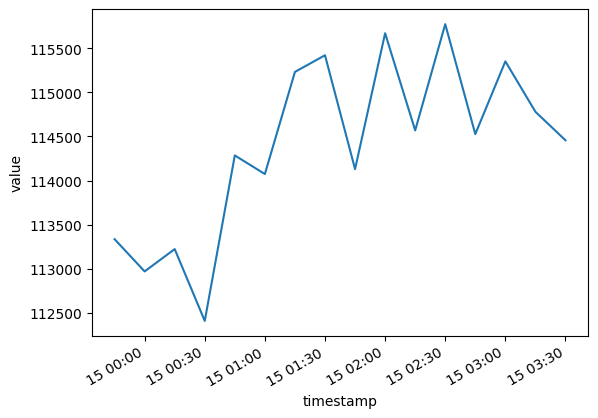

In [22]:
sns.lineplot(x="timestamp", y="value", data=df_results)
plt.gcf().autofmt_xdate()
plt.show()